# Elliptic Bitcoin graph components

This notebook loads the Elliptic Bitcoin dataset into `data/EllipticBitcoinDataset`, finds weakly connected components, and visualizes sampled connected subgraphs colored by label: licit, illicit, and unknown.

In [1]:
from pathlib import Path
import sys

import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "graph_structure.py").exists() else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from script.graph_structure import (
    build_undirected_graph,
    component_summary,
    load_elliptic_data,
    plot_connected_components,
)

DATA_ROOT = PROJECT_ROOT / "data" / "EllipticBitcoinDataset"
OUTPUT_DIR = PROJECT_ROOT / "figures" / "elliptic_components"
DATA_ROOT, OUTPUT_DIR

c:\Users\91983\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(WindowsPath('c:/Users/91983/Desktop/Emon/Courses/Stat 305/305C/data/EllipticBitcoinDataset'),
 WindowsPath('c:/Users/91983/Desktop/Emon/Courses/Stat 305/305C/figures/elliptic_components'))

In [2]:
data = load_elliptic_data(DATA_ROOT)
graph = build_undirected_graph(data)

print(data)
print(f"Connected components: {graph.number_of_nodes():,} nodes, {graph.number_of_edges():,} undirected edges")

summary_df = pd.DataFrame(component_summary(graph, data, limit=10))
summary_df

Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])
Connected components: 203,769 nodes, 234,355 undirected edges


,rank,nodes,edges,licit,illicit,unknown
0,1,7880,9164,2130,17,5733
1,2,7140,8493,1915,239,4986
2,3,6803,8623,1874,8,4921
3,4,6727,8588,954,18,5755
4,5,6621,8316,1268,11,5342
5,6,6393,7813,1675,33,4685
6,7,6048,7253,1101,102,4845
7,8,5894,7014,1605,158,4131
8,9,5693,8180,1410,30,4253
9,10,5598,6673,1216,5,4377


In [3]:
paths = plot_connected_components(
    data_root=DATA_ROOT,
    output_dir=OUTPUT_DIR,
    num_components=4,
    max_nodes_per_component=300,
)
paths

[WindowsPath('c:/Users/91983/Desktop/Emon/Courses/Stat 305/305C/figures/elliptic_components/component_01.png'),
 WindowsPath('c:/Users/91983/Desktop/Emon/Courses/Stat 305/305C/figures/elliptic_components/component_02.png'),
 WindowsPath('c:/Users/91983/Desktop/Emon/Courses/Stat 305/305C/figures/elliptic_components/component_03.png'),
 WindowsPath('c:/Users/91983/Desktop/Emon/Courses/Stat 305/305C/figures/elliptic_components/component_04.png')]

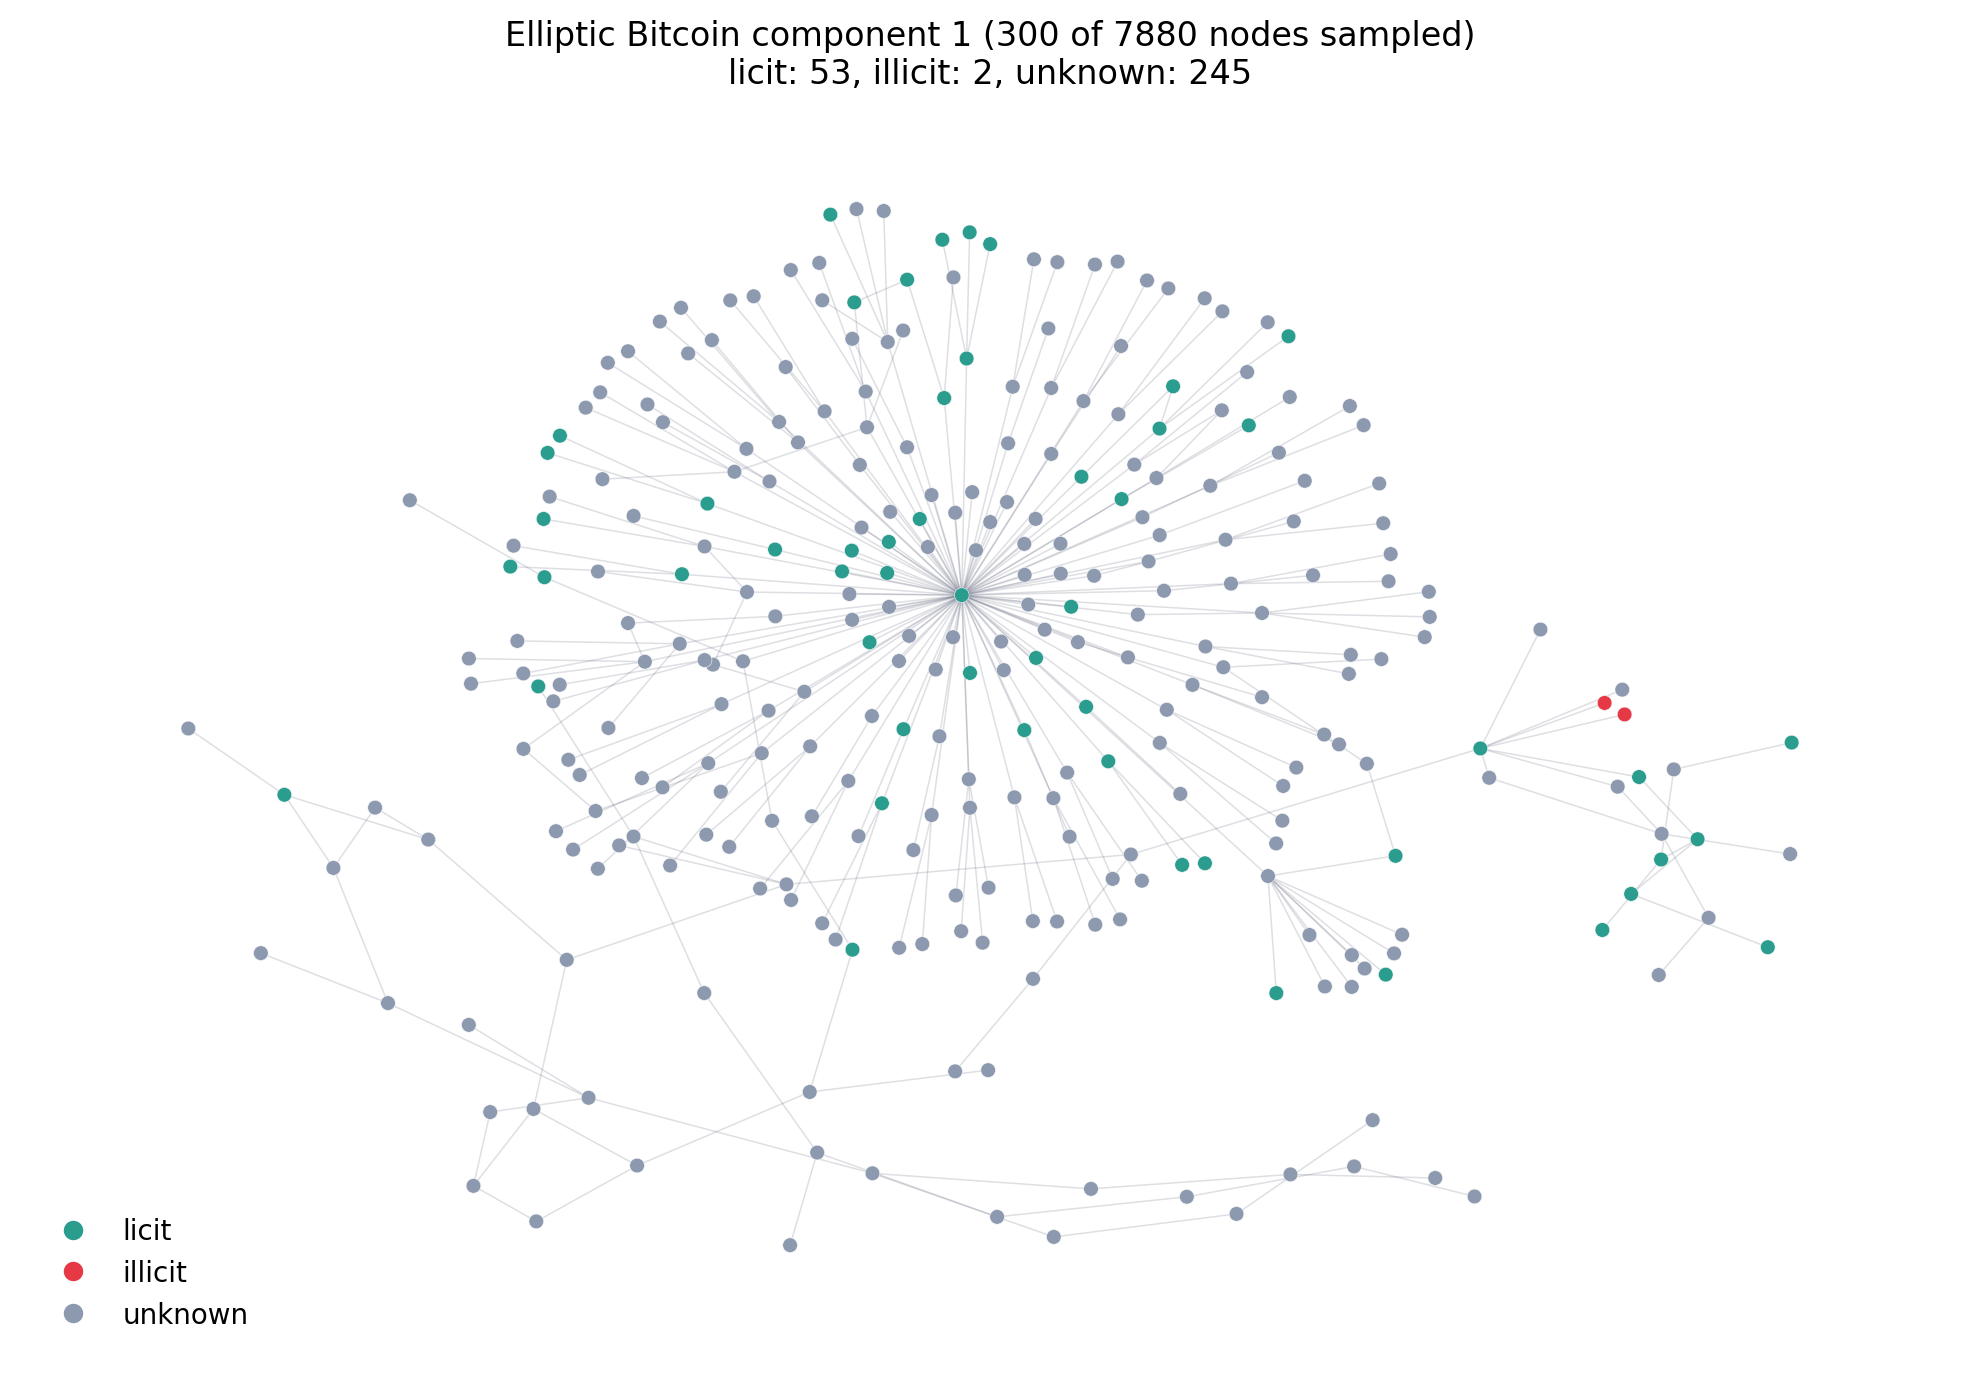

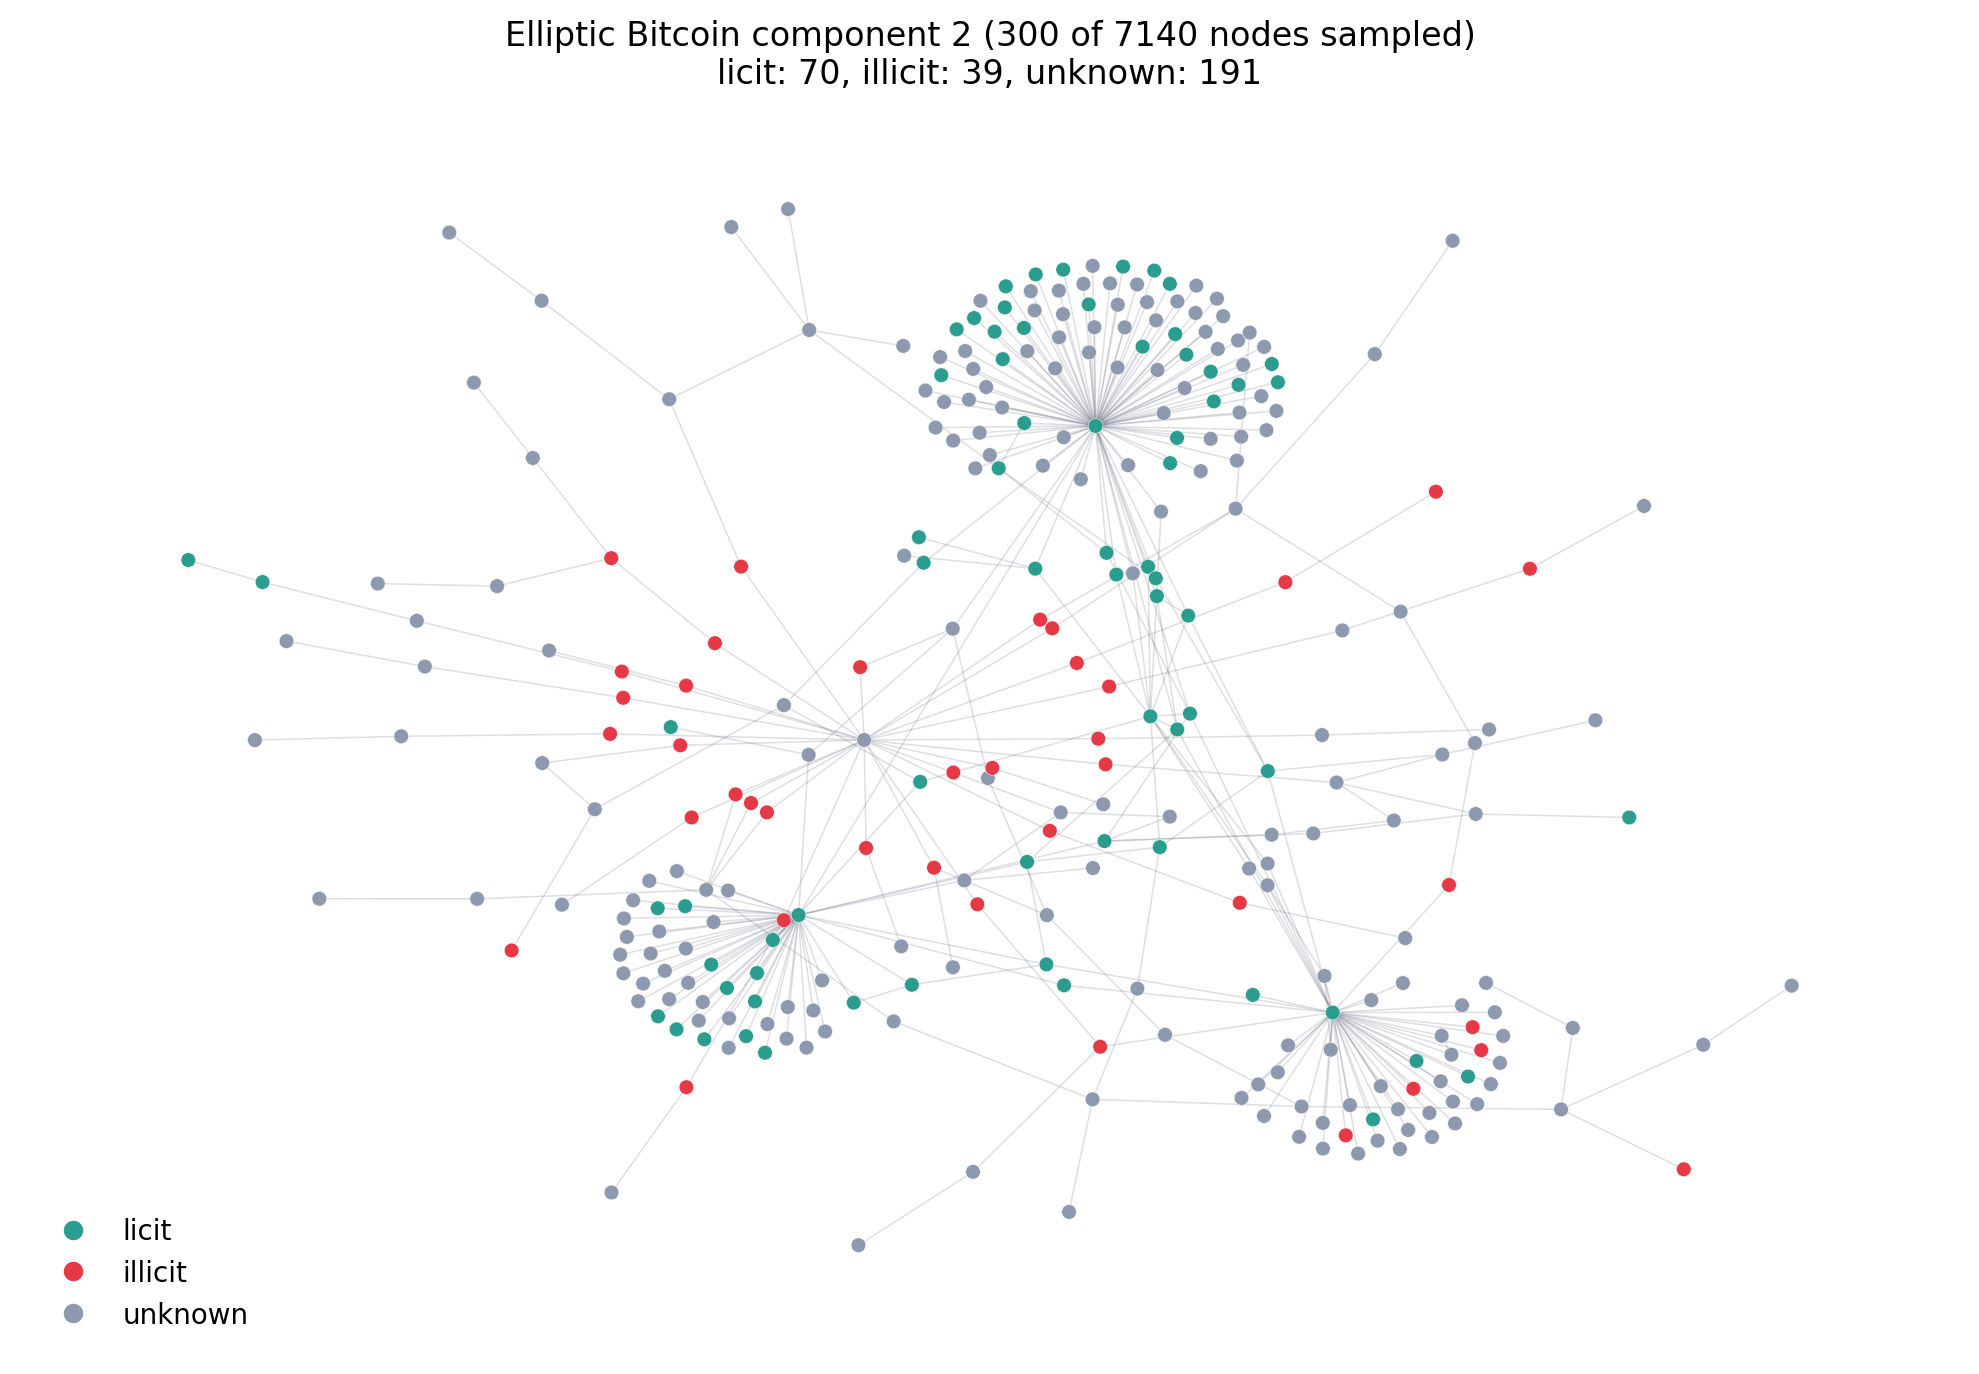

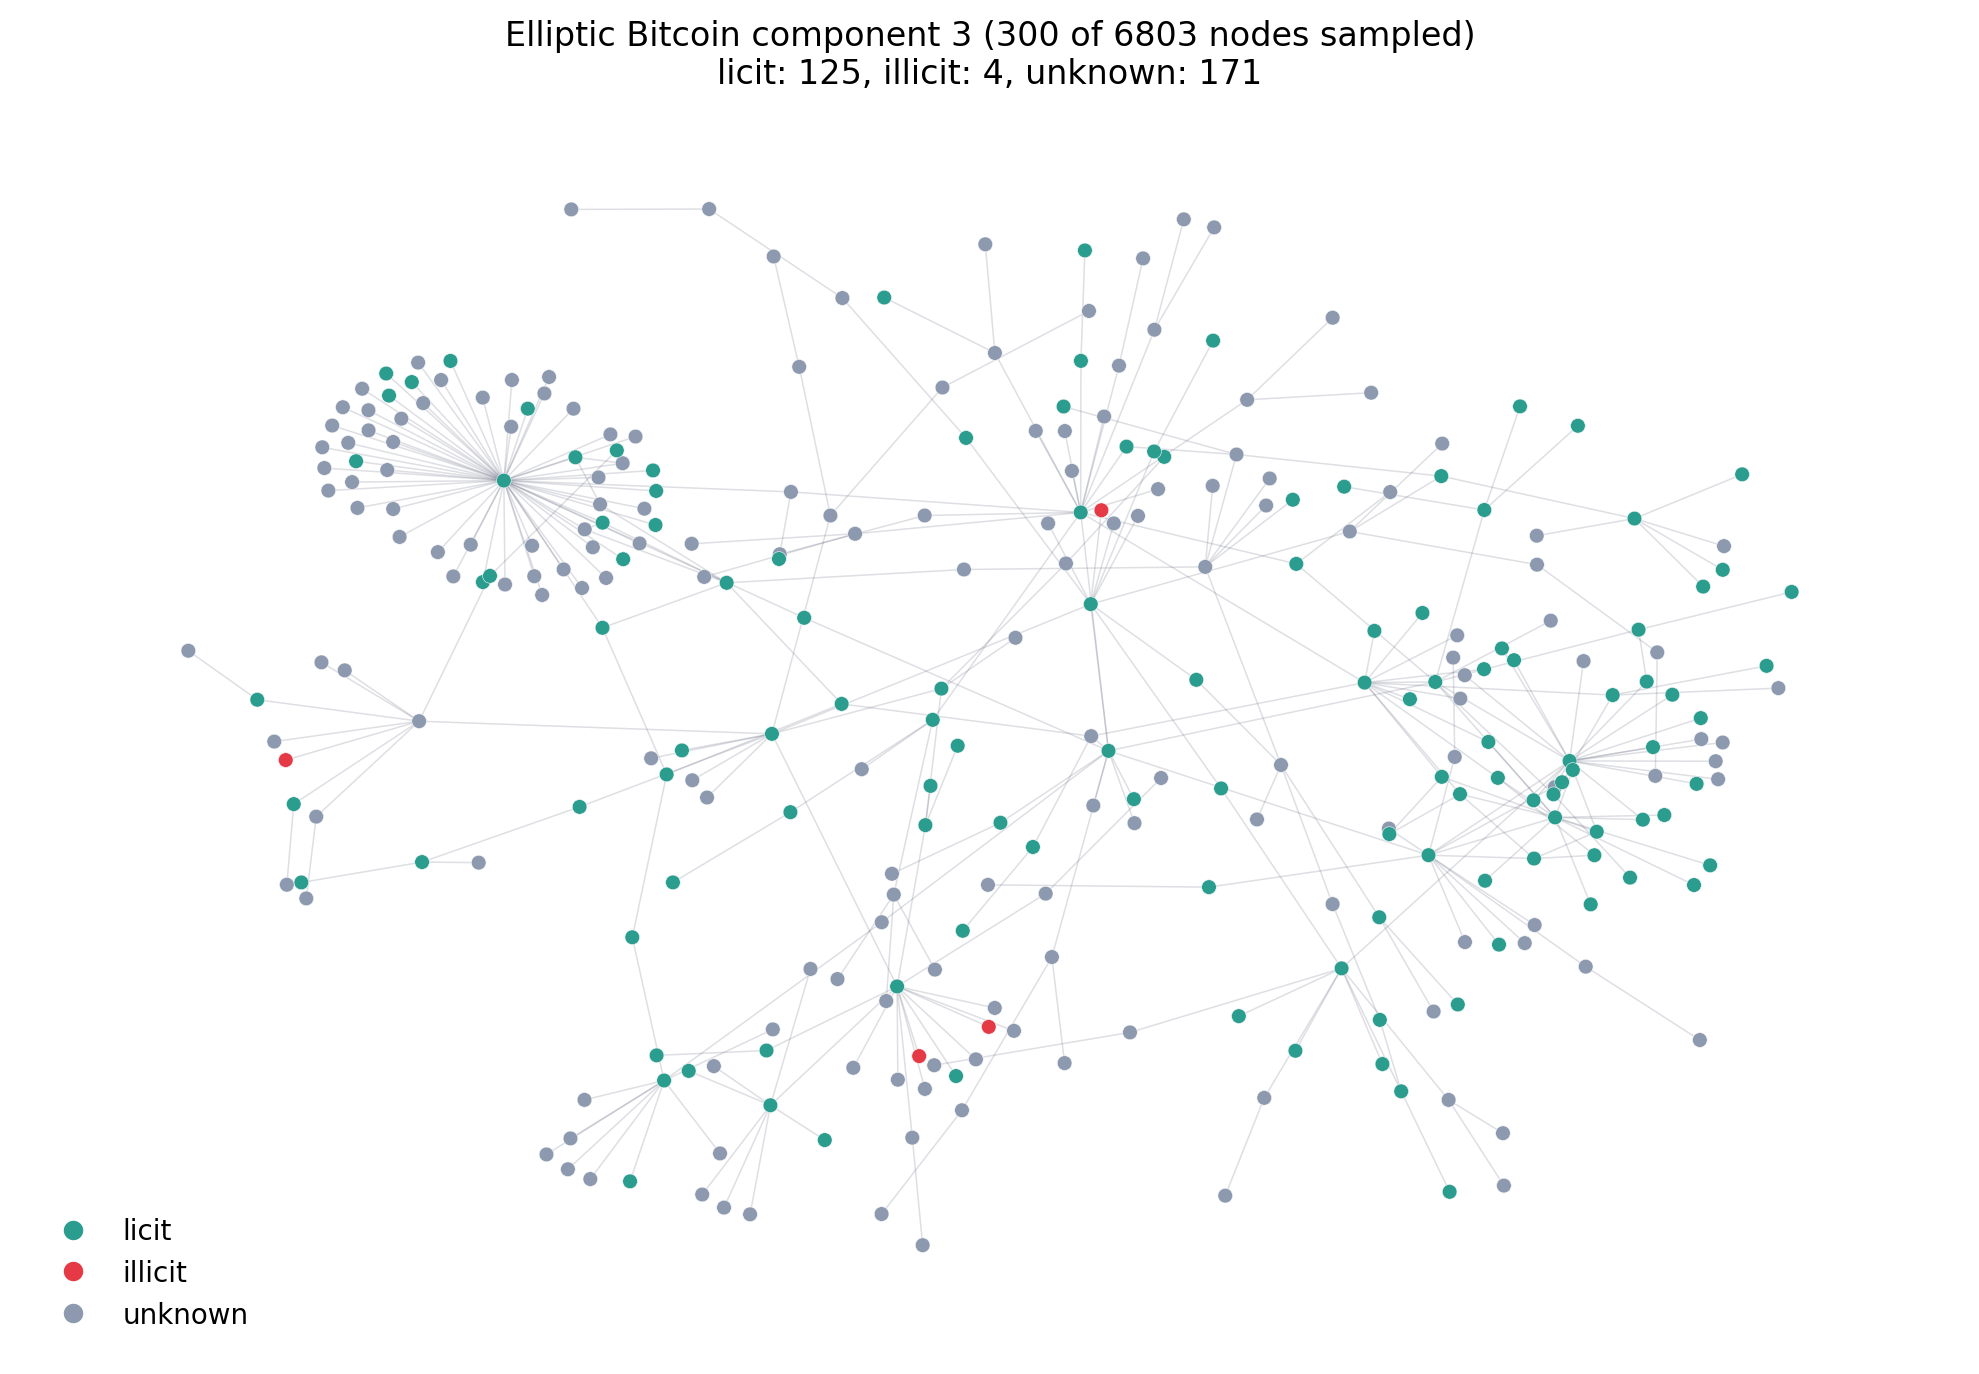

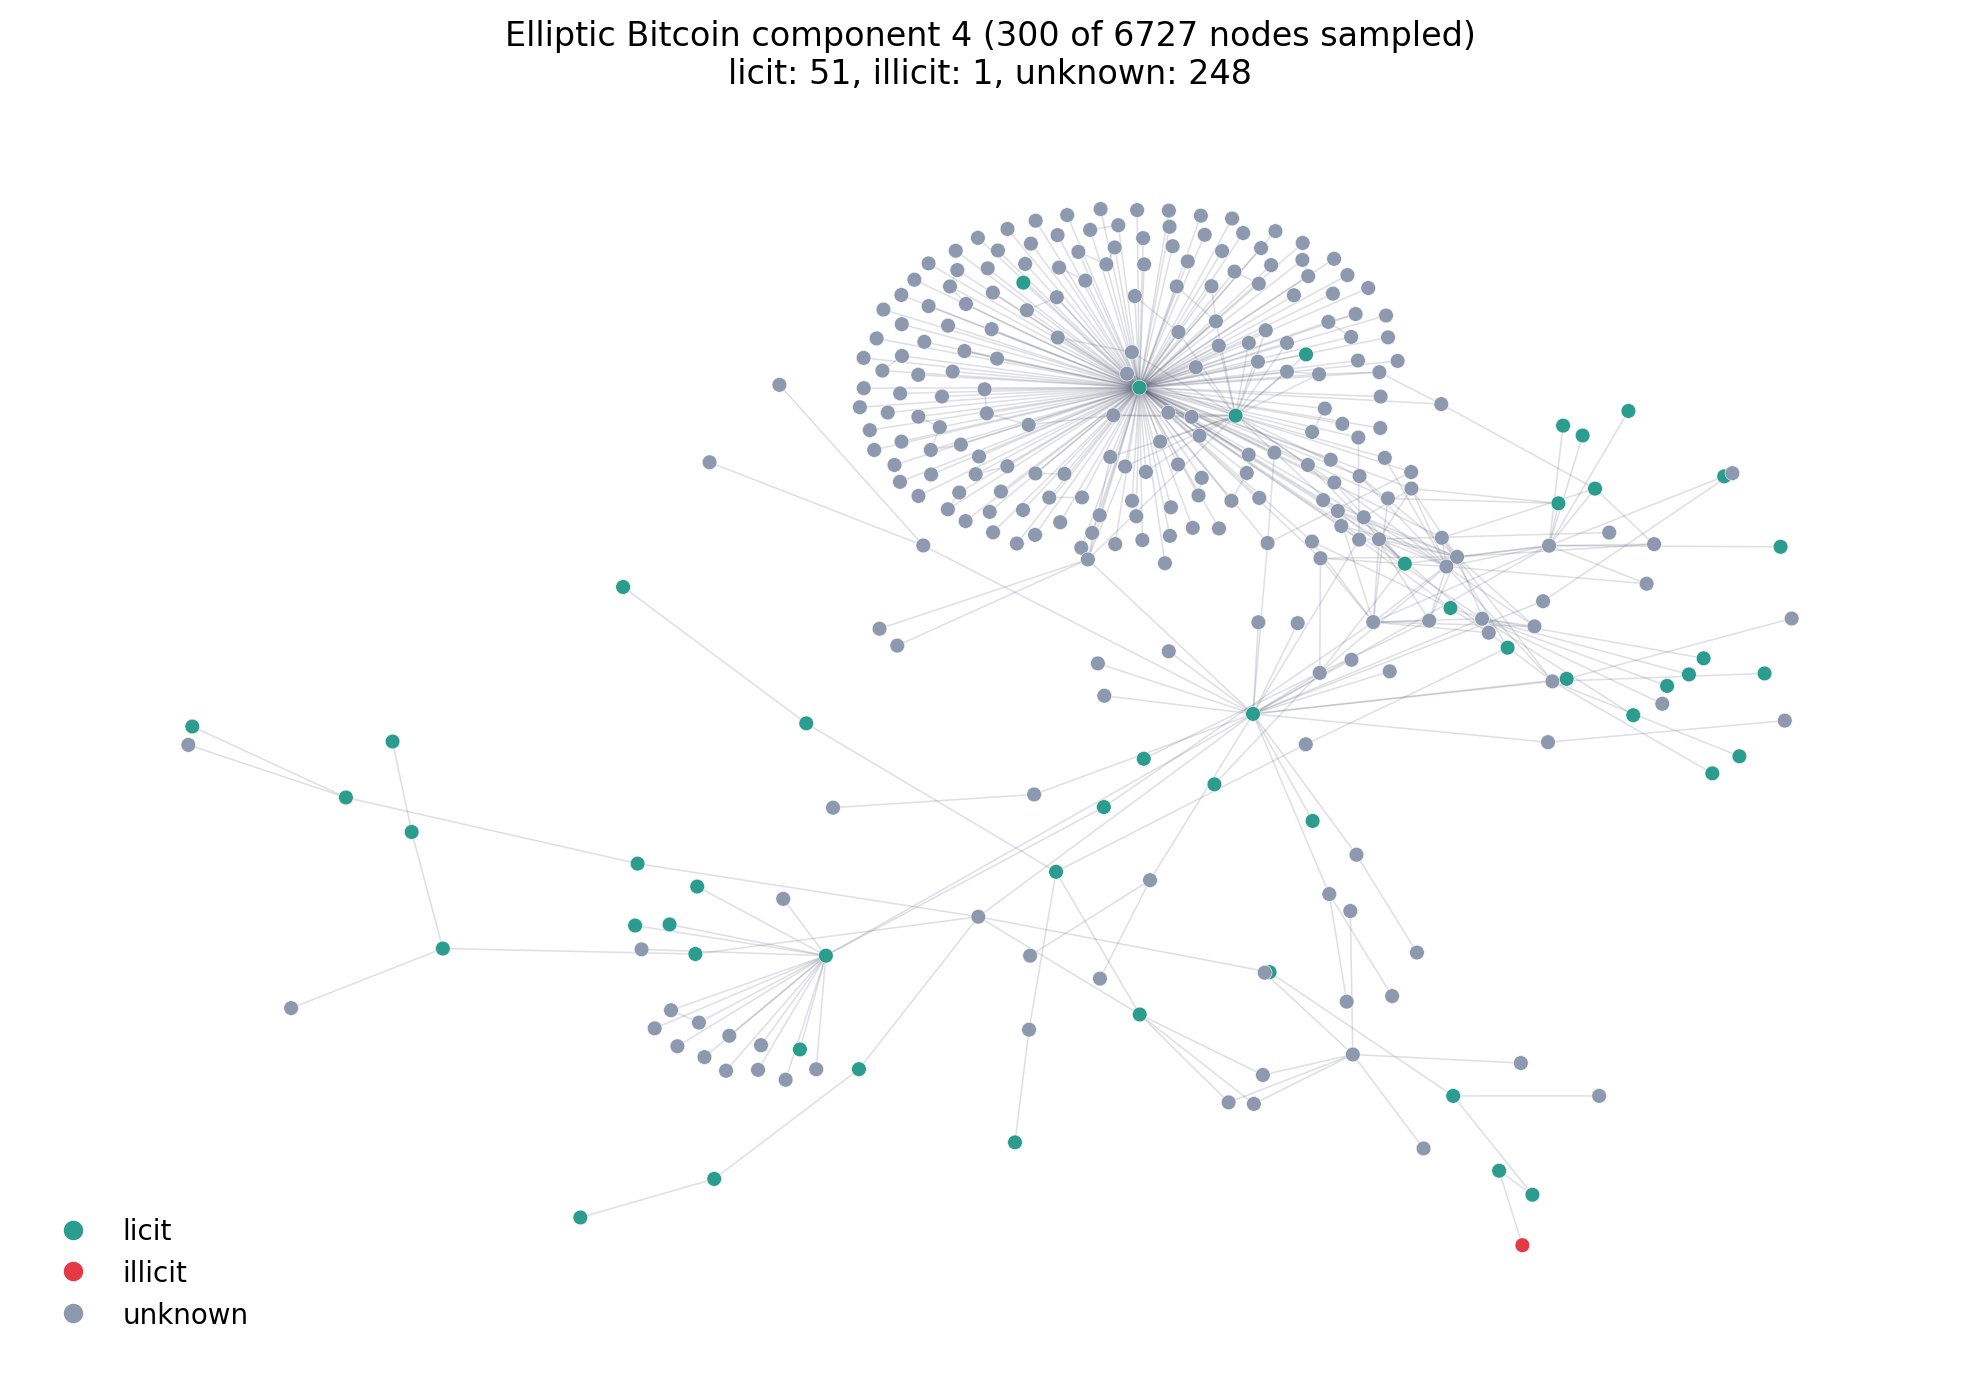

In [4]:
from IPython.display import Image, display

for path in paths:
    display(Image(filename=str(path)))